**Import Libraries**


In [4]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

**Load** **Dataset**

In [7]:
from google.colab import files

uploaded = files.upload()

Saving fraud_insurance_claims.csv to fraud_insurance_claims (1).csv


In [8]:
df = pd.read_csv('fraud_insurance_claims.csv')

print(df.head())

   months_as_customer  age  policy_number     policy_bind_date policy_state  \
0                 328   48         521585  2014-10-17 00:00:00           OH   
1                 228   42         342868  2006-06-27 00:00:00           IN   
2                 134   29         687698  2000-09-06 00:00:00           OH   
3                 256   41         227811  1990-05-25 00:00:00           IL   
4                 228   44         367455  2014-06-06 00:00:00           IL   

  policy_csl  policy_deductable  policy_annual_premium  umbrella_limit  \
0    250/500               1000                1406.91               0   
1    250/500               2000                1197.22         5000000   
2    100/300               2000                1413.14         5000000   
3    250/500               2000                1415.74         6000000   
4   500/1000               1000                1583.91         6000000   

   insured_zip  ... witnesses police_report_available total_claim_amount  \
0   

In [9]:
print(df.shape)

print(df.info())

print(df.describe())

(1000, 39)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_

**Handling missing Values**

In [10]:
print(df.isnull().sum())

months_as_customer              0
age                             0
policy_number                   0
policy_bind_date                0
policy_state                    0
policy_csl                      0
policy_deductable               0
policy_annual_premium           0
umbrella_limit                  0
insured_zip                     0
insured_sex                     0
insured_education_level         0
insured_occupation              0
insured_hobbies                 0
insured_relationship            0
capital-gains                   0
capital-loss                    0
incident_date                   0
incident_type                   0
collision_type                  0
incident_severity               0
authorities_contacted          91
incident_state                  0
incident_city                   0
incident_location               0
incident_hour_of_the_day        0
number_of_vehicles_involved     0
property_damage                 0
bodily_injuries                 0
witnesses     

In [12]:
df.replace('?', np.nan, inplace=True)

**Check Missing Values Again**

In [13]:
print(df.isnull().sum())

months_as_customer               0
age                              0
policy_number                    0
policy_bind_date                 0
policy_state                     0
policy_csl                       0
policy_deductable                0
policy_annual_premium            0
umbrella_limit                   0
insured_zip                      0
insured_sex                      0
insured_education_level          0
insured_occupation               0
insured_hobbies                  0
insured_relationship             0
capital-gains                    0
capital-loss                     0
incident_date                    0
incident_type                    0
collision_type                 178
incident_severity                0
authorities_contacted           91
incident_state                   0
incident_city                    0
incident_location                0
incident_hour_of_the_day         0
number_of_vehicles_involved      0
property_damage                360
bodily_injuries     

**Fill Missing Values**

In [14]:
for column in df.columns:
    if df[column].dtype == 'object':
        df[column].fillna(df[column].mode()[0], inplace=True)

In [15]:
print(df.duplicated().sum())

0


**Remove Unnecessary Columns**

In [25]:
df.drop([
    'policy_number',
    'policy_bind_date',
    'incident_location',
    'incident_date',
    'insured_zip'
], axis=1, inplace=True, errors='ignore')

**Fraud Distribution**

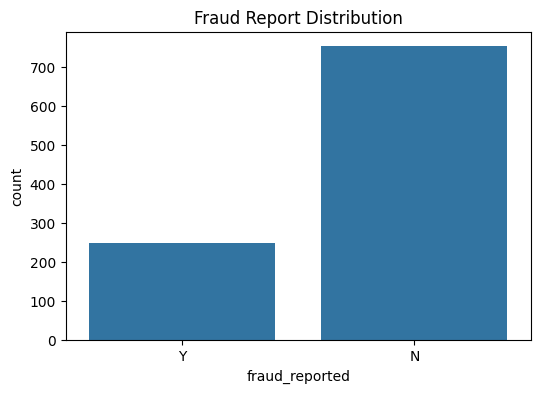

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(x='fraud_reported', data=df)

plt.title('Fraud Report Distribution')

plt.show()

**Incident Type Distribution**

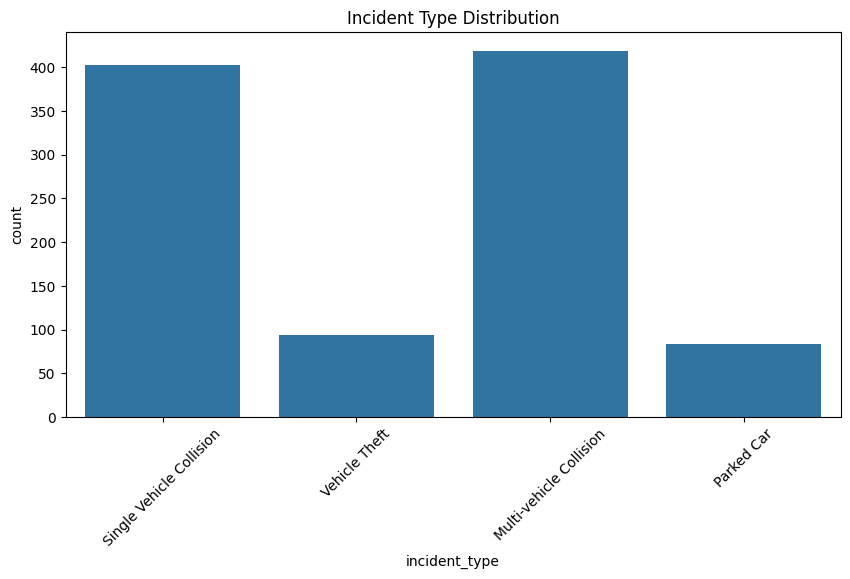

In [27]:
plt.figure(figsize=(10,5))

sns.countplot(x='incident_type', data=df)

plt.xticks(rotation=45)

plt.title('Incident Type Distribution')

plt.show()

**Collision Type Distribution**

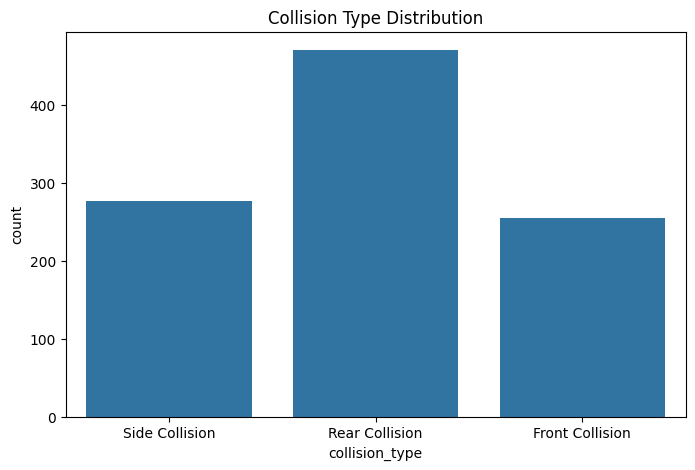

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(x='collision_type', data=df)

plt.title('Collision Type Distribution')

plt.show()

**Age Distribution**

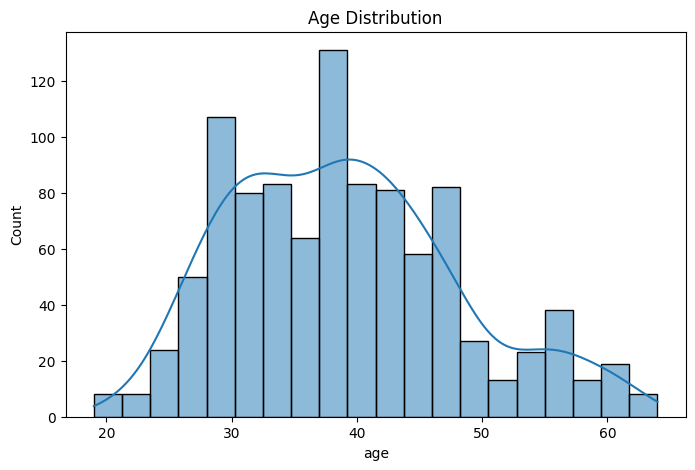

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20, kde=True)

plt.title('Age Distribution')

plt.show()

**Claim Amount Distribution**

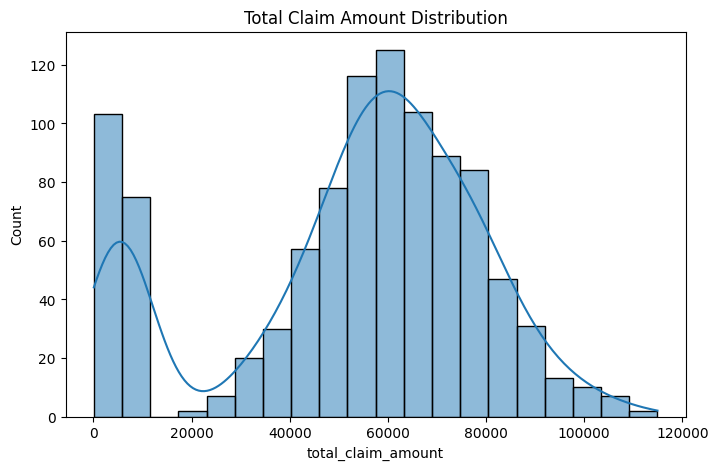

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(df['total_claim_amount'], bins=20, kde=True)

plt.title('Total Claim Amount Distribution')

plt.show()

**Fraud by Gender**

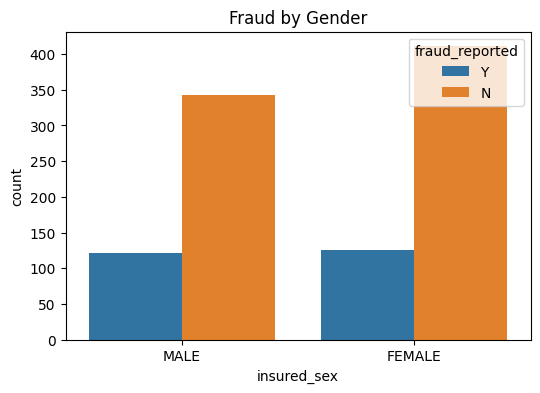

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(x='insured_sex', hue='fraud_reported', data=df)

plt.title('Fraud by Gender')

plt.show()

**Correlation Heatmap**

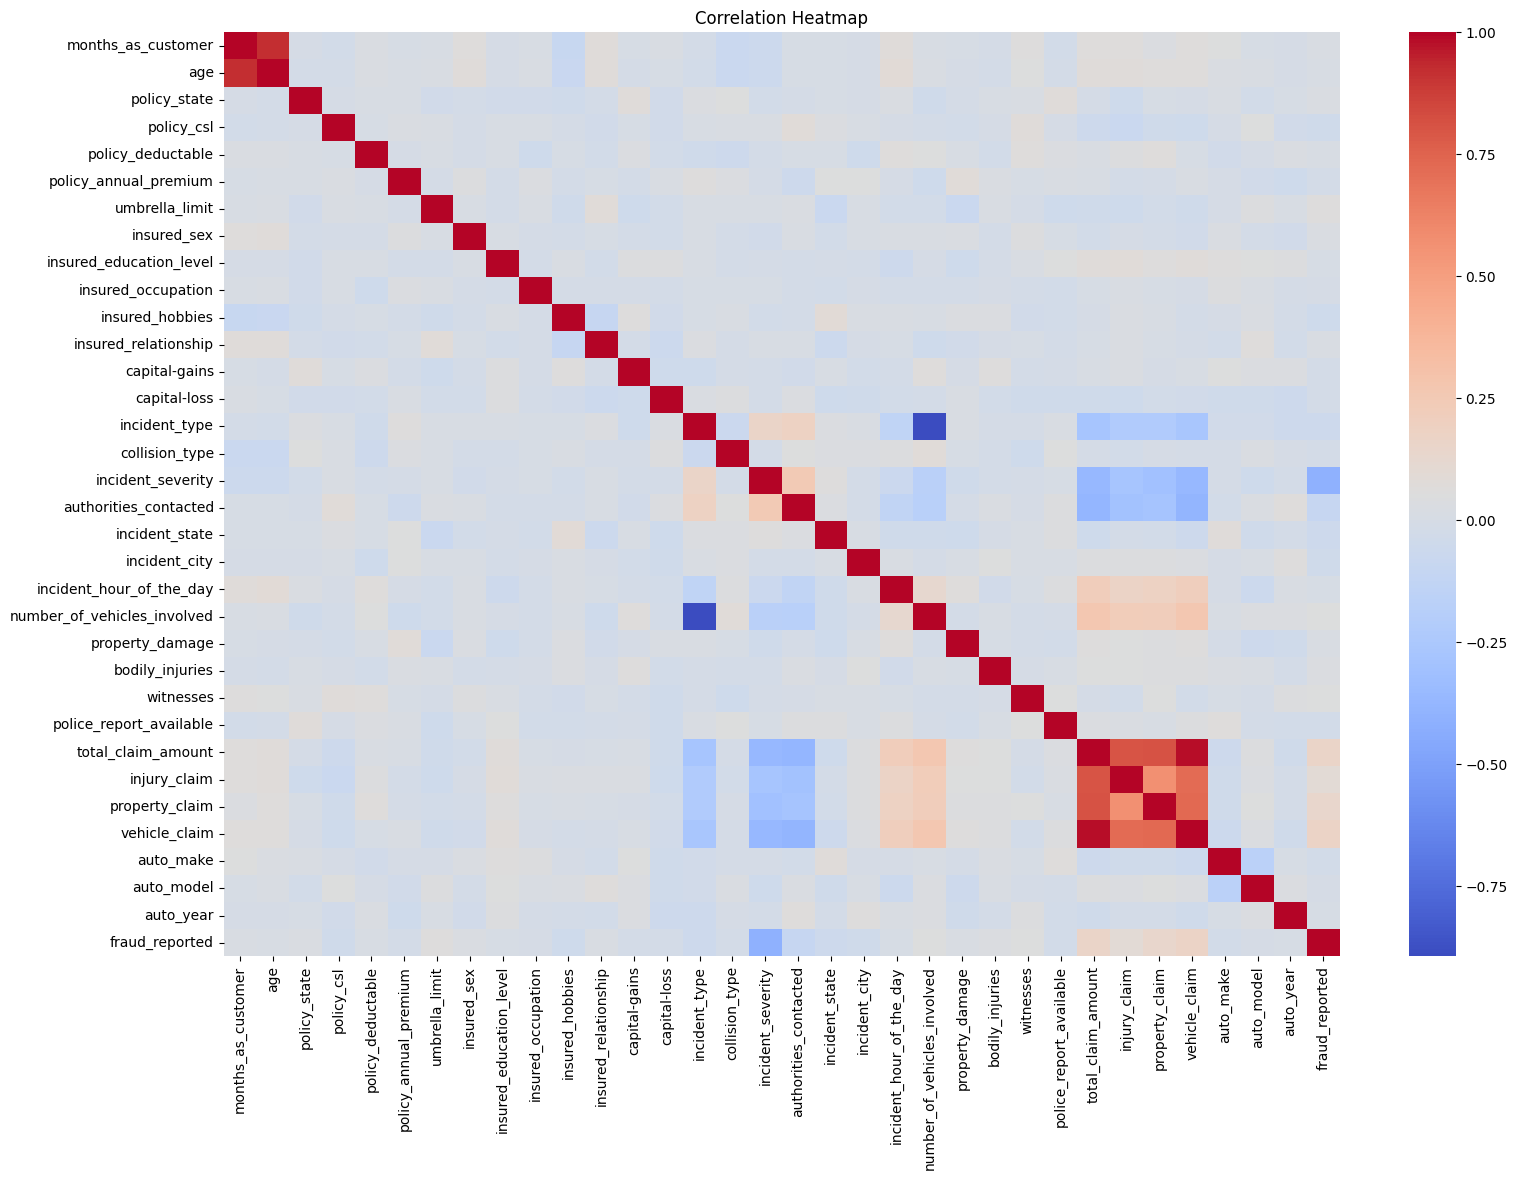

In [32]:
le = LabelEncoder()

df_heatmap = df.copy()

for column in df_heatmap.columns:
    if df_heatmap[column].dtype == 'object':
        df_heatmap[column] = le.fit_transform(df_heatmap[column])

plt.figure(figsize=(18,12))

sns.heatmap(df_heatmap.corr(), cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

**Outlier Detection**

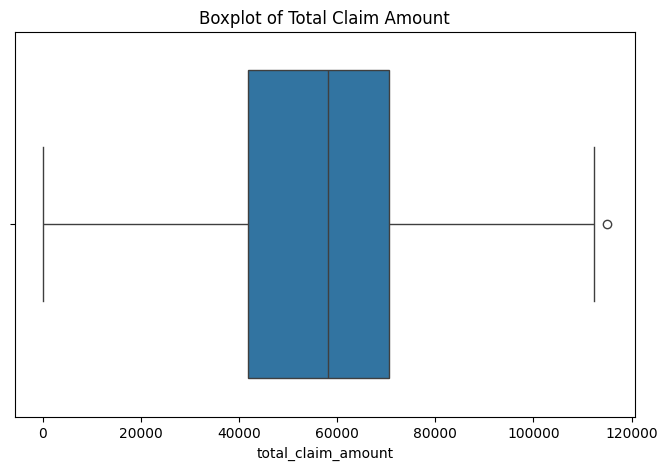

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['total_claim_amount'])

plt.title('Boxplot of Total Claim Amount')

plt.show()

**Remove Outliers**

In [34]:
Q1 = df['total_claim_amount'].quantile(0.25)

Q3 = df['total_claim_amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

df = df[
    (df['total_claim_amount'] >= lower_bound) &
    (df['total_claim_amount'] <= upper_bound)
]

print(df.shape)

(999, 34)


**Label Encoding**

In [36]:
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

In [38]:
X = df.drop('fraud_reported', axis=1)

y = df['fraud_reported']

print(X.head())

print(y.head())

   months_as_customer  age  policy_state  policy_csl  policy_deductable  \
0                 328   48             2           1               1000   
1                 228   42             1           1               2000   
2                 134   29             2           0               2000   
3                 256   41             0           1               2000   
4                 228   44             0           2               1000   

   policy_annual_premium  umbrella_limit  insured_sex  \
0                1406.91               0            1   
1                1197.22         5000000            1   
2                1413.14         5000000            0   
3                1415.74         6000000            0   
4                1583.91         6000000            1   

   insured_education_level  insured_occupation  ...  bodily_injuries  \
0                        4                   2  ...                1   
1                        4                   6  ...           

**Train Test Split**

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Logistic Regression**

In [42]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print('Logistic Regression Accuracy:')

print(accuracy_score(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy:
0.77
              precision    recall  f1-score   support

           0       0.77      1.00      0.87       153
           1       1.00      0.02      0.04        47

    accuracy                           0.77       200
   macro avg       0.88      0.51      0.46       200
weighted avg       0.82      0.77      0.67       200



**Logistic Regression Confusion Matrix**

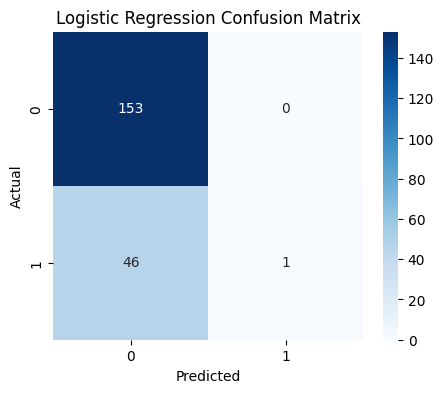

In [43]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Logistic Regression Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

**Decision Tree Classifier**

In [44]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print('Decision Tree Accuracy:')

print(accuracy_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy:
0.78
              precision    recall  f1-score   support

           0       0.88      0.83      0.85       153
           1       0.53      0.62      0.57        47

    accuracy                           0.78       200
   macro avg       0.70      0.72      0.71       200
weighted avg       0.79      0.78      0.79       200



**Decision Tree Confusion Matrix**

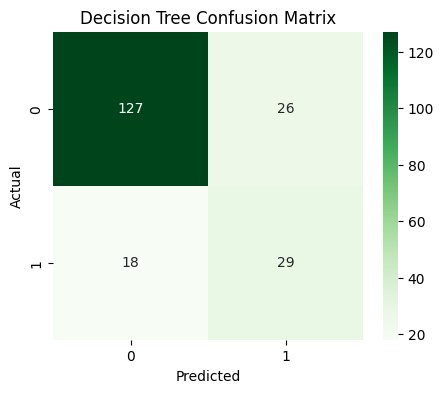

In [45]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title('Decision Tree Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

**Random Forest Classifier**

In [46]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print('Random Forest Accuracy:')

print(accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy:
0.755
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       153
           1       0.47      0.32      0.38        47

    accuracy                           0.76       200
   macro avg       0.64      0.60      0.61       200
weighted avg       0.73      0.76      0.74       200



**Random Forest Confusion Matrix**

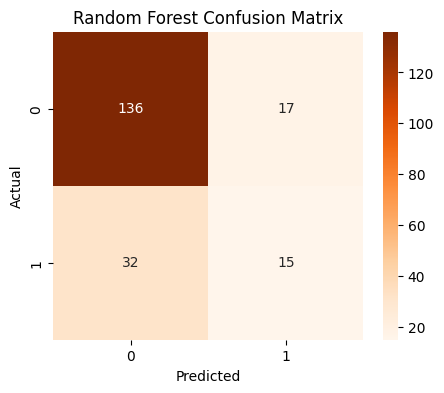

In [47]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')

plt.title('Random Forest Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

**Naive Bayes Classifier**

In [48]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print('Naive Bayes Accuracy:')

print(accuracy_score(y_test, y_pred_nb))

print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy:
0.69
              precision    recall  f1-score   support

           0       0.79      0.80      0.80       153
           1       0.33      0.32      0.33        47

    accuracy                           0.69       200
   macro avg       0.56      0.56      0.56       200
weighted avg       0.69      0.69      0.69       200



**Naive Bayes Confusion Matrix**

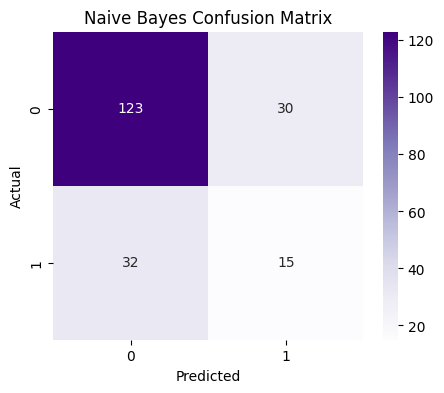

In [49]:
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')

plt.title('Naive Bayes Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

**Conclusion**

The project focused on detecting fraudulent insurance claims using machine learning.
Data preprocessing techniques such as handling missing values, removing unnecessary columns, encoding, and outlier removal were performed.

Exploratory Data Analysis was conducted using graphs and visualizations.